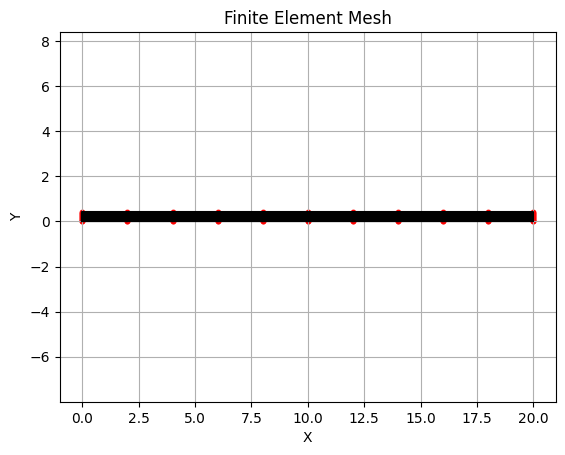

In [ ]:
#Generating Geometry And Mesh
import numpy as np

#input Parameters
Lx = float(input("Enter length in x-direction: "))
Ly = Lx/50

nx = int(input("Enter number of elements in x-direction: "))

ny = int(input("Enter number of elements in y-direction: "))



E = 210e9      # Young's modulus
nu = 0.3       # Poisson's ratio
t = 0.01       # thickness
bx = 0         #Body force along x
by = 0         #Body force along y direction

# Nodes and Elements

dx = Lx / nx
dy = Ly / ny


nodes = []
for j in range(ny + 1):
    for i in range(nx + 1):
        nodes.append([i * dx, j * dy])

nodes = np.array(nodes)
n_nodes = len(nodes)

#Elements


elements = []
for j in range(ny):
    for i in range(nx):
        n1 = j*(nx+1) + i
        n2 = n1 + 1
        n3 = n2 + (nx+1)
        n4 = n1 + (nx+1)
        elements.append([n1, n2, n3, n4])

elements = np.array(elements)
n_elem = len(elements)

#plotting Mesh
import matplotlib.pyplot as plt

def plot_mesh(nodes, elements):
    plt.figure()

    for elem in elements:
        x = nodes[elem, 0]
        y = nodes[elem, 1]

        # Close the rectangle
        x = np.append(x, x[0])
        y = np.append(y, y[0])

        plt.plot(x, y, 'k-')  # black lines

    plt.scatter(nodes[:,0], nodes[:,1], color='red', s=10)

    plt.title("Finite Element Mesh")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis('equal')
    plt.grid(True)

    plt.show()

# Call function
plot_mesh(nodes, elements)

In [ ]:
#code for elemental stiffness matrix , body force vector , traction force vector


# Gauss Points
gauss_pts = [(-1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3), -1/np.sqrt(3)),
             ( 1/np.sqrt(3),  1/np.sqrt(3)),
             (-1/np.sqrt(3),  1/np.sqrt(3))]


def element_stiffness(coords, E, nu, t):
    
    # coords in array containing 4 coordinates of the element
    
    # Material matrix (plane stress)
    D = (E/(1 - nu**2)) * np.array([
        [1, nu, 0],
        [nu, 1, 0],
        [0, 0, (1-nu)/2]
    ])

    Ke = np.zeros((8,8))

    for xi, eta in gauss_pts:

        # Shape function derivatives
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)
        invJ = np.linalg.inv(J)

        # B matrix
        B = np.zeros((3,8))
        for i in range(4):
            dN = invJ @ dN_dxi[i]

            B[0,2*i]   = dN[0]
            B[1,2*i+1] = dN[1]
            B[2,2*i]   = dN[1]
            B[2,2*i+1] = dN[0]

        Ke += B.T @ D @ B * detJ * t

    return Ke 

In [ ]:
# generating mass matrix
def element_mass(coords, rho, t):

    Me = np.zeros((8, 8))

    for xi, eta in gauss_pts:

        # Shape functions
        N = 0.25 * np.array([
            (1 - xi)*(1 - eta),
            (1 + xi)*(1 - eta),
            (1 + xi)*(1 + eta),
            (1 - xi)*(1 + eta)
        ])

        # Shape function derivatives (for Jacobian)
        dN_dxi = 0.25 * np.array([
            [-(1-eta), -(1-xi)],
            [ (1-eta), -(1+xi)],
            [ (1+eta),  (1+xi)],
            [-(1+eta),  (1-xi)]
        ])

        # Jacobian
        J = np.zeros((2,2))
        for i in range(4):
            J += np.outer(dN_dxi[i], coords[i])

        detJ = np.linalg.det(J)

        if detJ <= 0:
            raise ValueError("Jacobian determinant is non-positive!")

        # Construct N matrix (2x8)
        Nmat = np.zeros((2, 8))
        for i in range(4):
            Nmat[0, 2*i]   = N[i]
            Nmat[1, 2*i+1] = N[i]

        # Mass matrix integration
        Me += rho * (Nmat.T @ Nmat) * detJ * t

    return Me

In [ ]:
# Density (add this input)
rho = float(input("Enter density of material: "))

# Total DOFs (2 per node)
ndof = 2 * n_nodes

# Initialize global matrices
K_global = np.zeros((ndof, ndof))
M_global = np.zeros((ndof, ndof))


# Assembly loop
for elem in elements:
    
    # Node indices
    n1, n2, n3, n4 = elem

    # Coordinates of element nodes (4x2)
    coords = np.array([
        nodes[n1],
        nodes[n2],
        nodes[n3],
        nodes[n4]
    ])

    # Get element matrices
    Ke = element_stiffness(coords, E, nu, t)
    Me = element_mass(coords, rho, t)

    # DOF mapping (VERY IMPORTANT)
    dof_map = [
        2*n1, 2*n1+1,
        2*n2, 2*n2+1,
        2*n3, 2*n3+1,
        2*n4, 2*n4+1
    ]

    # Assemble into global matrices
    for i in range(8):
        for j in range(8):
            K_global[dof_map[i], dof_map[j]] += Ke[i, j]
            M_global[dof_map[i], dof_map[j]] += Me[i, j]



In [ ]:
# Example: fixing left edge nodes (x = 0)
fixed_dofs = []

for i, (x, y) in enumerate(nodes):
    if x == 0:   # left edge
        fixed_dofs.extend([2*i, 2*i+1])  # fix u and v

all_dofs = np.arange(ndof)
free_dofs = np.setdiff1d(all_dofs, fixed_dofs)

K_red = K_global[np.ix_(free_dofs, free_dofs)]
M_red = M_global[np.ix_(free_dofs, free_dofs)]

In [ ]:
# Calculating eigenvalues and eigenvectors for modal analysis
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(M_red) @ K_red)

# Remove small/negative numerical errors
eigvals = np.real(eigvals)
eigvals[eigvals < 0] = 0

idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]


In [ ]:
omega = np.sqrt(eigvals)          # rad/s
frequencies = omega / (2*np.pi)   # Hz

print("Natural Frequencies (Hz):\n", frequencies[:10])

Natural Frequencies (Hz):
 [  241.07881477  1525.75358821  4372.26453604  5750.41378843
  8886.36342268 15392.97188638 17407.19037973 24234.01243661
 29537.15930651 35589.93653976]


In [ ]:
for i in range(eigvecs.shape[1]):
    eigvecs[:, i] = eigvecs[:, i] / np.max(np.abs(eigvecs[:, i]))

num_modes = eigvecs.shape[1]
mode_shapes_full = np.zeros((ndof, num_modes))

for i in range(len(free_dofs)):
    mode_shapes_full[free_dofs[i], :] = eigvecs[i, :]

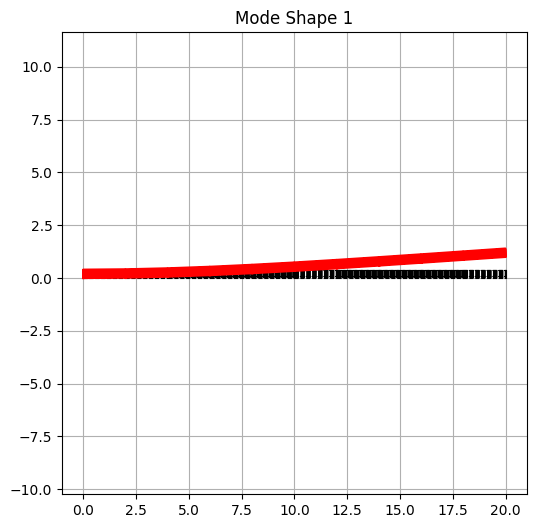

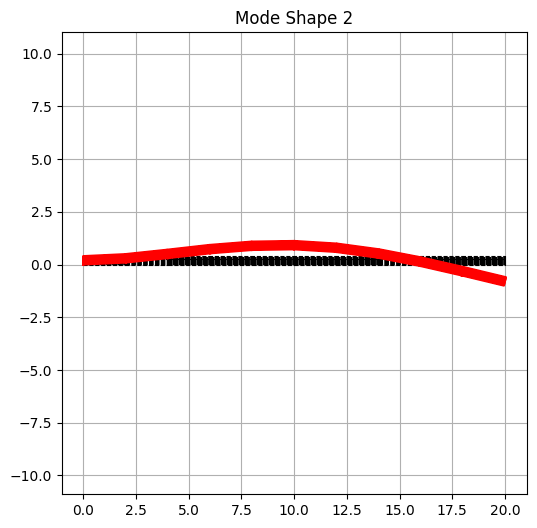

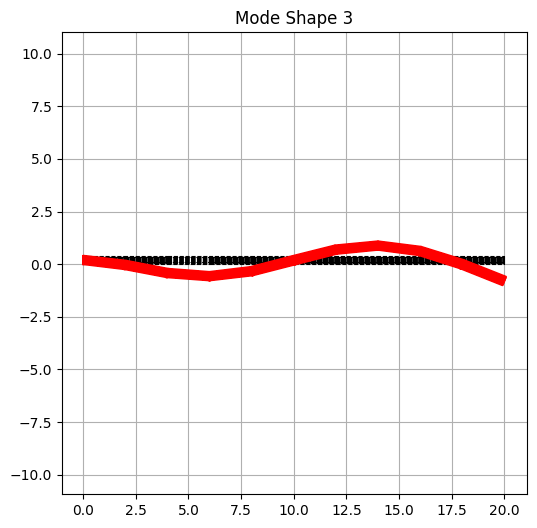

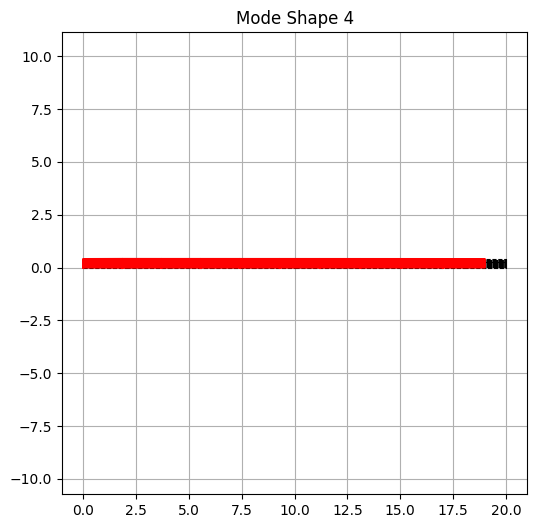

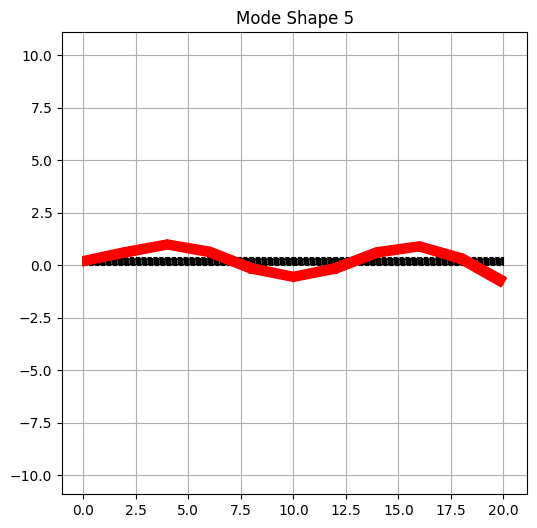

In [ ]:
import matplotlib.pyplot as plt

def plot_all_modes(nodes, elements, mode_shapes_full, scale=1):

    num_modes = mode_shapes_full.shape[1]

    for mode_num in range(5):

        u = mode_shapes_full[0::2, mode_num]
        v = mode_shapes_full[1::2, mode_num]

        deformed_nodes = nodes + scale * np.column_stack((u, v))

        plt.figure(figsize=(6,6))

        # original mesh
        for elem in elements:
            pts = nodes[elem]
            pts = np.vstack((pts, pts[0]))
            plt.plot(pts[:,0], pts[:,1], 'k--', linewidth=0.8)

        # deformed mesh
        for elem in elements:
            pts = deformed_nodes[elem]
            pts = np.vstack((pts, pts[0]))
            plt.plot(pts[:,0], pts[:,1], 'r')

        plt.title(f"Mode Shape {mode_num+1}")
        plt.axis("equal")
        plt.grid(True)
        plt.show()


# Call function
plot_all_modes(nodes, elements, mode_shapes_full, scale=1)

nx = 10  -->  f5 = 8886.3634 Hz
nx = 20  -->  f5 = 5737.7905 Hz
nx = 30  -->  f5 = 5734.3609 Hz
nx = 40  -->  f5 = 5300.2449 Hz
nx = 50  -->  f5 = 4912.2606 Hz
nx = 60  -->  f5 = 4690.1185 Hz
nx = 70  -->  f5 = 4551.6277 Hz


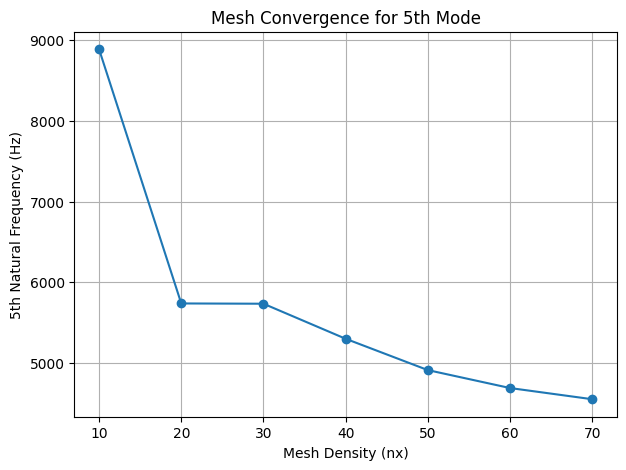

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

mesh_sizes = [10, 20, 30, 40, 50, 60,70]

fifth_mode_freq = []

for nx in mesh_sizes:

    ny = nx

    # -------------------------
    # Regenerate mesh
    # -------------------------
    dx = Lx / nx
    dy = Ly / ny

    nodes = []

    for j in range(ny + 1):
        for i in range(nx + 1):
            nodes.append([i*dx, j*dy])

    nodes = np.array(nodes)

    elements = []

    for j in range(ny):
        for i in range(nx):

            n1 = j*(nx+1) + i
            n2 = n1 + 1
            n3 = n2 + (nx+1)
            n4 = n1 + (nx+1)

            elements.append([n1, n2, n3, n4])

    elements = np.array(elements)

    # -------------------------
    # Global matrices
    # -------------------------
    n_nodes = len(nodes)
    ndof = 2 * n_nodes

    K_global = np.zeros((ndof, ndof))
    M_global = np.zeros((ndof, ndof))

    for elem in elements:

        coords = nodes[elem]

        Ke = element_stiffness(coords, E, nu, t)
        Me = element_mass(coords, rho, t)

        dof_map = []

        for node in elem:
            dof_map.extend([2*node, 2*node+1])

        for i in range(8):
            for j in range(8):

                K_global[dof_map[i], dof_map[j]] += Ke[i,j]
                M_global[dof_map[i], dof_map[j]] += Me[i,j]

    # -------------------------
    # Boundary conditions
    # -------------------------
    fixed_dofs = []

    for i, (x, y) in enumerate(nodes):
        if x == 0:
            fixed_dofs.extend([2*i, 2*i+1])

    all_dofs = np.arange(ndof)

    free_dofs = np.setdiff1d(all_dofs, fixed_dofs)

    K_red = K_global[np.ix_(free_dofs, free_dofs)]
    M_red = M_global[np.ix_(free_dofs, free_dofs)]

    # -------------------------
    # Solve eigenvalue problem
    # -------------------------
    eigvals, eigvecs = eigh(K_red, M_red)

    eigvals[eigvals < 0] = 0

    omega = np.sqrt(eigvals)

    frequencies = omega / (2*np.pi)

    # Store 5th mode frequency
    fifth_mode_freq.append(frequencies[4])

    print(f"nx = {nx}  -->  f5 = {frequencies[4]:.4f} Hz")


# -------------------------
# Plot convergence graph
# -------------------------
plt.figure(figsize=(7,5))

plt.plot(mesh_sizes, fifth_mode_freq, marker='o')

plt.xlabel("Mesh Density (nx)")
plt.ylabel("5th Natural Frequency (Hz)")
plt.title("Mesh Convergence for 5th Mode")

plt.grid(True)
plt.show()